# Quantization

In [1]:
from model import Classifier

model = Classifier.load_from_checkpoint(
    "lightning_logs/mnist_cnn/version_1/checkpoints/epoch=4-step=8595.ckpt"
)

model.eval()

Classifier(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=3136, out_features=10, bias=True)
)

In [2]:
from data import ImageDataModule

data_module = ImageDataModule(batch_size=32)

data_module.prepare_data()
data_module.setup()

test_loader = data_module.test_dataloader()

In [3]:
import torch
from torch.quantization import quantize_dynamic

model_quantized = quantize_dynamic(
    model,
    {torch.nn.Linear},
    dtype=torch.qint8
)

In [4]:
import time

def measure_time(model, data_loader):
    model.eval()
    
    start_time = time.time()

    with torch.no_grad():
        for inputs, _ in data_loader:
            _ = model(inputs)
            
    end_time = time.time()
        
    return end_time - start_time

original_time = measure_time(model, test_loader)

quant_time = measure_time(model_quantized, test_loader)

print(f"Original Model Time: {original_time:.2f}s")
print(f"Quantized Model Time: {quant_time:.2f}s")

Original Model Time: 4.64s
Quantized Model Time: 4.25s


# Benchmark

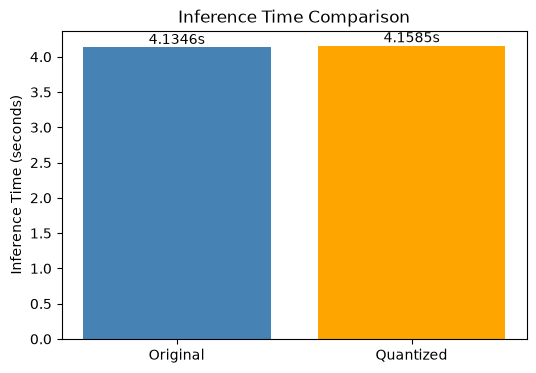

In [5]:
# Inferance time comparison

original_time = measure_time(model, test_loader)
quant_time = measure_time(model_quantized, test_loader)

import matplotlib.pyplot as plt

models = ["Original", "Quantized"]
times = [original_time, quant_time]

plt.figure(figsize=(6, 4))

plt.bar(
    models,
    times,
    color=["steelblue", "orange"]
)

plt.ylabel("Inference Time (seconds)")
plt.title("Inference Time Comparison")

for i, value in enumerate(times):
    plt.text(
        i,
        value,
        f"{value:.4f}s",
        ha="center",
        va="bottom"
    )
plt.savefig(
    "figures/inference_time_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



Original: 198.83 KB
Quantized: 107.72 KB


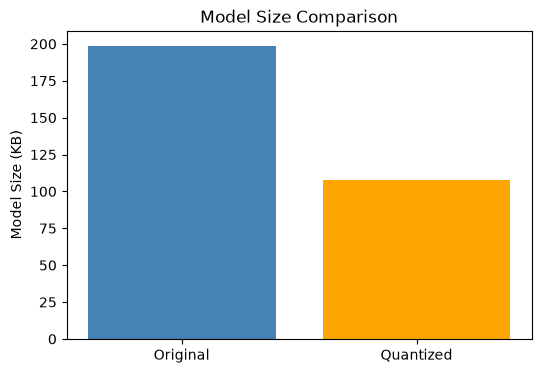

In [6]:
# Model size comparision

import os
import torch

torch.save(model.state_dict(), "original_model.pth")
torch.save(model_quantized.state_dict(), "quantized_model.pth")

original_size = os.path.getsize("original_model.pth") / 1024
quant_size = os.path.getsize("quantized_model.pth") / 1024

print(f"Original: {original_size:.2f} KB")
print(f"Quantized: {quant_size:.2f} KB")


sizes = [original_size, quant_size]

plt.figure(figsize=(6,4))

plt.bar(
    ["Original", "Quantized"],
    sizes,
    color=["steelblue", "orange"]
)

plt.ylabel("Model Size (KB)")
plt.title("Model Size Comparison")

plt.savefig(
    "figures/model_size_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In [7]:
# Compare accuracy

def evaluate_accuracy(model, loader):
    model.eval()
    
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == y).sum().item()
            total += y.size(0)

    return correct / total


original_acc = evaluate_accuracy(model, test_loader)
quant_acc = evaluate_accuracy(model_quantized, test_loader)

print(original_acc)
print(quant_acc)


0.9901
0.9901


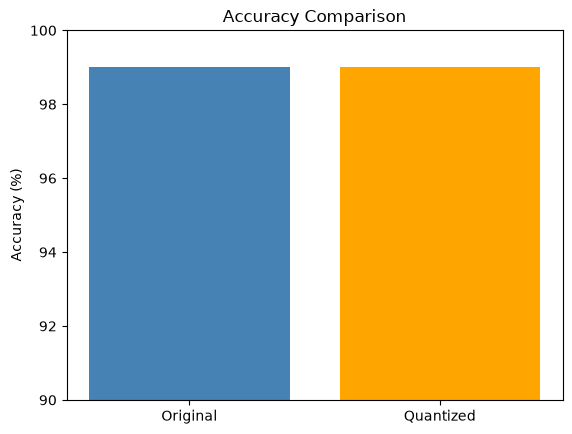

In [8]:
accuracies = [
    original_acc * 100,
    quant_acc * 100
]

plt.bar(
    ["Original", "Quantized"],
    accuracies,
    color=["steelblue", "orange"]
)

plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison")

plt.ylim(90, 100)

plt.savefig(
    "figures/accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()